# Diagnóstico post-hoc: clustering del MLP de una capa

Este notebook responde una pregunta descriptiva: **¿hay señal de clustering en validation aunque una seed tenga rango efectivo bajo?** Selecciona el mínimo error predictivo de las cinco seeds sin usar rango como filtro, pero conserva y reporta el umbral formal. No modifica los FAIL anteriores, no ajusta con etiquetas y no construye test.

In [1]:
# ruff: noqa: E402, E501
import json
import random
import sys
import time
from dataclasses import asdict, replace
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display

from koopman_jepa.paper_config import (
    PaperCheckpointReplayConfig,
    load_paper_mlp_one_hidden_development_config,
)
from koopman_jepa.paper_data import PAPER_REGIME_NAMES, PaperRegimeDataset, generate_paper_master
from koopman_jepa.paper_evaluation import (
    evaluate_paper_mlp_clustering_gate,
    evaluate_paper_mlp_seed_clustering,
)
from koopman_jepa.paper_model import PaperTemporalJEPA
from koopman_jepa.paper_training import (
    make_paper_loader,
    run_paper_train_validation_with_checkpoint,
    summarize_seed_checkpoint,
    verify_paper_checkpoint_replay,
)

plt.style.use("seaborn-v0_8-whitegrid")
torch.use_deterministic_algorithms(True)

In [2]:
config = load_paper_mlp_one_hidden_development_config(
    ROOT / "configs" / "paper_mlp_one_hidden_development.yaml"
)
diagnostic_gate = replace(config.checkpoint_gate, min_validation_effective_rank=1.0)
replay_config = PaperCheckpointReplayConfig(metric_absolute_tolerance=1e-8)
train_dataset = PaperRegimeDataset(config.data, "train", generate_paper_master)
validation_dataset = PaperRegimeDataset(config.data, "val", generate_paper_master)
assert len(train_dataset) == 64 * len(PAPER_REGIME_NAMES) == 1152
assert len(validation_dataset) == 32 * len(PAPER_REGIME_NAMES) == 576
assert {train_dataset.sample_key(i) for i in range(len(train_dataset))}.isdisjoint(
    {validation_dataset.sample_key(i) for i in range(len(validation_dataset))}
)
print("Cambio diagnóstico único:")
print(f"  rango de selección formal: {config.checkpoint_gate.min_validation_effective_rank}")
print(f"  rango de selección descriptiva: {diagnostic_gate.min_validation_effective_rank}")
print("Datos, seeds, modelo, optimización y clustering permanecen iguales. Test no instanciado.")

Cambio diagnóstico único:
  rango de selección formal: 4.0
  rango de selección descriptiva: 1.0
Datos, seeds, modelo, optimización y clustering permanecen iguales. Test no instanciado.


In [3]:
models, summaries, replays, times = {}, [], {}, {}
for seed in config.sweep.seeds:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    run_config = replace(config.train, seed=seed)
    model = PaperTemporalJEPA(config.model)
    started = time.perf_counter()
    run = run_paper_train_validation_with_checkpoint(
        model, train_dataset, validation_dataset, run_config, diagnostic_gate
    )
    assert run.selection is not None
    replay = verify_paper_checkpoint_replay(
        model, run, validation_dataset, run_config, replay_config, expected_epoch=run.selection.epoch
    )
    assert replay.passed
    times[seed] = time.perf_counter() - started
    models[seed], replays[seed] = model, replay
    summary = summarize_seed_checkpoint(seed, run.selection)
    summaries.append(summary)
    formal_rank = summary.validation_effective_rank >= config.checkpoint_gate.min_validation_effective_rank
    print(
        f"seed={seed} epoch={summary.checkpoint_epoch} val/base={summary.validation_loss_ratio:.3f} "
        f"rank={summary.validation_effective_rank:.2f} formal_rank={'PASS' if formal_rank else 'FAIL'}"
    )
assert set(models) == set(config.sweep.seeds)
print(f"Cinco checkpoints descriptivos reproducidos; tiempo={sum(times.values()):.1f}s")

seed=10 epoch=6 val/base=0.014 rank=8.66 formal_rank=PASS


seed=11 epoch=7 val/base=0.008 rank=2.10 formal_rank=FAIL


seed=12 epoch=5 val/base=0.014 rank=7.66 formal_rank=PASS


seed=13 epoch=6 val/base=0.020 rank=4.25 formal_rank=PASS


seed=14 epoch=6 val/base=0.007 rank=6.33 formal_rank=PASS
Cinco checkpoints descriptivos reproducidos; tiempo=210.2s


In [4]:
@torch.no_grad()
def collect_embeddings(model, run_config):
    device = torch.device(run_config.device)
    model.to(device).eval()
    embeddings, labels = [], []
    for context, _, batch_labels in make_paper_loader(validation_dataset, run_config, shuffle=False):
        embeddings.append(model.online_encoder(context.to(device)).cpu().numpy())
        labels.append(batch_labels.numpy())
    return np.concatenate(embeddings), np.concatenate(labels)

clustering_metrics = []
reference_labels = None
for seed in config.sweep.seeds:
    embeddings, labels = collect_embeddings(models[seed], replace(config.train, seed=seed))
    reference_labels = labels if reference_labels is None else reference_labels
    assert np.array_equal(labels, reference_labels)
    clustering_metrics.append(
        evaluate_paper_mlp_seed_clustering(embeddings, labels, seed, config.clustering)
    )
clustering_gate = evaluate_paper_mlp_clustering_gate(
    clustering_metrics, config.sweep, config.clustering_gate
)
print(json.dumps(asdict(clustering_gate), indent=2))

{
  "all_seeds_present": true,
  "all_finite": true,
  "overall_mean_purity": 0.5075694444444445,
  "worst_seed_mean_purity": 0.4760416666666667,
  "seed_mean_purity_coefficient_of_variation": 0.04854837937282344,
  "worst_within_seed_purity_std": 0.013482554385662444,
  "failed_seeds": [
    10,
    11,
    12,
    13,
    14
  ],
  "overall_mean_passed": false,
  "worst_seed_passed": false,
  "seed_variability_passed": true,
  "kmeans_stability_passed": true,
  "metrics": [
    {
      "seed": 10,
      "mean_purity": 0.5194444444444445,
      "purity_std": 0.00650983793724051,
      "minimum_purity": 0.5069444444444444,
      "maximum_purity": 0.5295138888888888,
      "mean_matched_accuracy": 0.4721354166666667,
      "purities": [
        0.515625,
        0.5277777777777778,
        0.5069444444444444,
        0.5277777777777778,
        0.5173611111111112,
        0.5173611111111112,
        0.515625,
        0.5173611111111112,
        0.5260416666666666,
        0.515625,
    

seed epoch rank formal_rank purity_mean purity_sd purity_min purity_max matched
  10     6  8.66        True      51.94%     0.65%     50.69%     52.95%  47.21%
  11     7  2.10       False      52.62%     1.09%     51.04%     54.17%  48.85%
  12     5  7.66        True      47.60%     0.59%     46.35%     48.78%  44.05%
  13     6  4.25        True      53.59%     1.35%     51.39%     56.25%  49.63%
  14     6  6.33        True      48.02%     0.82%     46.70%     50.00%  45.59%


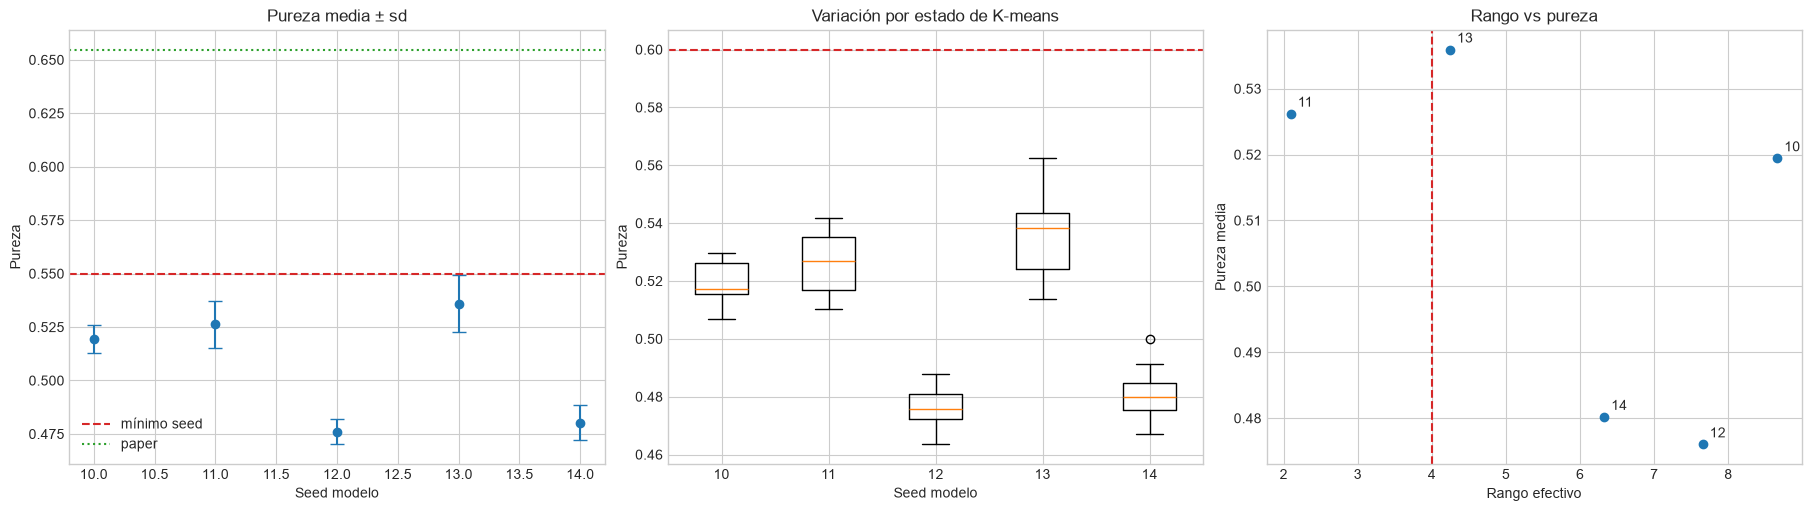

## Resultado descriptivo

- **FAIL descriptivo.**
- Pureza global: **50.76%**.
- Peor seed: **47.60%**.
- CV entre seeds: **0.049**.
- Mayor sd debida a K-means: **1.35%**.

Este resultado usa validation y un selector post-hoc sin filtro de rango. No reemplaza el FAIL formal ni habilita test.


In [5]:
summary_by_seed = {row.seed: row for row in summaries}
cluster_by_seed = {row.seed: row for row in clustering_metrics}
print("seed epoch rank formal_rank purity_mean purity_sd purity_min purity_max matched")
for seed in config.sweep.seeds:
    summary, cluster = summary_by_seed[seed], cluster_by_seed[seed]
    formal_rank = summary.validation_effective_rank >= config.checkpoint_gate.min_validation_effective_rank
    print(
        f"{seed:>4d} {summary.checkpoint_epoch:>5d} {summary.validation_effective_rank:>5.2f} "
        f"{str(formal_rank):>11s} {cluster.mean_purity:>11.2%} {cluster.purity_std:>9.2%} "
        f"{cluster.minimum_purity:>10.2%} {cluster.maximum_purity:>10.2%} {cluster.mean_matched_accuracy:>7.2%}"
    )

seeds = np.array(config.sweep.seeds)
means = np.array([cluster_by_seed[seed].mean_purity for seed in seeds])
stds = np.array([cluster_by_seed[seed].purity_std for seed in seeds])
ranks = np.array([summary_by_seed[seed].validation_effective_rank for seed in seeds])
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
axes[0].errorbar(seeds, means, yerr=stds, fmt="o", capsize=5)
axes[0].axhline(config.clustering_gate.min_worst_seed_mean_purity, color="tab:red", linestyle="--", label="mínimo seed")
axes[0].axhline(0.6548, color="tab:green", linestyle=":", label="paper")
axes[0].set(title="Pureza media ± sd", xlabel="Seed modelo", ylabel="Pureza")
axes[0].legend()
axes[1].boxplot([cluster_by_seed[seed].purities for seed in seeds], tick_labels=seeds)
axes[1].axhline(config.clustering_gate.min_overall_mean_purity, color="tab:red", linestyle="--")
axes[1].set(title="Variación por estado de K-means", xlabel="Seed modelo", ylabel="Pureza")
axes[2].scatter(ranks, means)
for seed, rank, mean in zip(seeds, ranks, means, strict=True):
    axes[2].annotate(str(seed), (rank, mean), xytext=(5, 5), textcoords="offset points")
axes[2].axvline(config.checkpoint_gate.min_validation_effective_rank, color="tab:red", linestyle="--")
axes[2].set(title="Rango vs pureza", xlabel="Rango efectivo", ylabel="Pureza media")
plt.show()

status = "PASS descriptivo" if clustering_gate.passed else "FAIL descriptivo"
display(Markdown(f"""## Resultado descriptivo

- **{status}.**
- Pureza global: **{clustering_gate.overall_mean_purity:.2%}**.
- Peor seed: **{clustering_gate.worst_seed_mean_purity:.2%}**.
- CV entre seeds: **{clustering_gate.seed_mean_purity_coefficient_of_variation:.3f}**.
- Mayor sd debida a K-means: **{clustering_gate.worst_within_seed_purity_std:.2%}**.

Este resultado usa validation y un selector post-hoc sin filtro de rango. No reemplaza el FAIL formal ni habilita test.
"""))

## Análisis posterior a la corrida

El diagnóstico produce una respuesta clara: hay estructura de clustering reproducible, pero su nivel es insuficiente. La pureza media global es `50.76%`, `9.24` puntos por debajo del mínimo local de desarrollo (`60%`) y `14.72` puntos por debajo del `65.48%` publicado. Las medias por seed van de `47.60%` a `53.59%`; ninguna alcanza el mínimo por seed de `55%`.

La variabilidad no es el problema principal. El CV entre seeds es `0.049`, por debajo del máximo `0.10`, y la mayor desviación debida a inicialización de K-means es `1.35%`, por debajo del máximo `3%`. Es decir, el resultado bajo es bastante estable: no depende de una seed afortunada ni de un K-means particularmente malo.

La seed 11, cuyo rango efectivo `2.10` causó el rechazo formal, obtiene pureza `52.62%` y es la segunda mejor. En cambio, seed 12 tiene rango `7.66` pero la peor pureza (`47.60%`). El panel rango-vs-pureza confirma que el umbral de rango no estaba escondiendo una reproducción exitosa; rango alto no garantiza separación de los 18 regímenes.

Conclusión: con encoder directo `6144→32`, predictor `32→64→32` y la optimización local actual, **no reproducimos** el `65.48%` del paper. El siguiente cambio limpio es probar la otra ambigüedad arquitectónica documentada, el encoder reconciliado `6144→64→32`, manteniendo dataset, predictor, seeds, optimización y evaluación. Test continúa sin abrirse.